# Basic Neural network

✨ Building a NN (Neural network) requires piecing together components to perform a particular task.

**Task**: Given an (3x3) image of black and white pixels, <u>the model predicts if the image contains more white pixels than black pixels</u>. Note that there are better architectures than the one we will build for image datasets.

The network we are going to build is a **Single-Layer Perceptron**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils.basic_nn import draw_image_cell_image, create_black_white_image_dataset

# Reloads external functions when their code changes into this notebook.
%load_ext autoreload
%autoreload 1
# %aimport will only reload those files
# %aimport utils.bboxes
%aimport utils.basic_nn

## Dataset

### Explain dataset

In [2]:
one_image, one_label = create_black_white_image_dataset(1)

In [3]:
one_image[0]

array([[0, 1, 0],
       [1, 0, 1],
       [1, 1, 1]])

An image in the dataset is an array of ones and zeros, where $1$ represents a white pixel and $0$ represents black pixel.

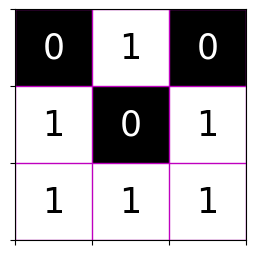

In [4]:
draw_image_cell_image(one_image[0])

In [5]:
print("⭐️ Image's label:", int(one_label[0]))

⭐️ Image's label: 1


* The **label** (i.e., its ground truth) for that image is either **1** for there are more white pixels than black pixels and **0** otherwise.

### Create Dataset

In [6]:
num_samples = 5000 # How many images in the dataset
images, labels = create_black_white_image_dataset(num_samples)

### Preprocess The Dataset

**Inputs And Labels:**
- Inputs can also be noted as **features** or **X**.
    - The input is the image_array. We feed the model the input.
    - Each pixel is a single feature.
    - The model expects a $(n, 9)$ input vector, so we reshape the (3x3) image array into $(n, 9)$.
      - The $n$ represents how many **samples** are in the dataset, one sample is one image.

- Labels can also be noted as **target**, **ground truth** or **Y**.
    - We compare the model's prediction to the label to get the **Cost**, i.e., how well it performs.

In [7]:
X = images.reshape( num_samples, 9)
X.shape

(5000, 9)

In [8]:
Y = labels.reshape(-1, 1) # the reshape adds an extra dimension -> , 1)
Y.shape

(5000, 1)

⭐️ **Normalize**
- For certain datasets like images, we normalize the image pixel data to be values between $[0,1]$, this allows the model to train faster and converge better.
    - Regular **grayscale** pixel values are:
        - $0$ value represents a black pixel, and $255$ value represents a white pixel.
- However, since our image data is stored as **0s and 1s**, not in pixel values, it's already in a small, stable range. We can **skip** normalization for this dataset.

## Create Single-Layer Perceptron Model

<p align="center">
    <img src="./showcase_images/single-layer-perceptron.png" alt="logistic regression network" width="95%">
</p>

### Network description:
- A Single-layer perceptron has no hidden layers.

- $x_1$ is the first pixel of an image, $x_9$ is the ninth pixel of the same image.
  - Each input pixel has its own corresponding weight $w_1$, $w_2$, ... $w_9$
    - Each weight determines the strength of its corresponding pixel input.

**Training Process:**

1. **Forward propagation:** Feed the images input to the model and calculate how the model performs (the **Cost** error).
2. **Backward propagation:** Adjust model's learned parameters to make it perform better.
   1. Use the Cost to calculate gradients using the [chain rule](../Resouces/chain_rule.ipynb) (how much each $w$ and $b$ contributed to the error)
   2. Use [Batch Gradient Descent](Optimizers/batch_gradient_descent.ipynb) to update the learned parameters $(w, b)$.

### Learned Parameters

`w` (weights) & `b` (bias).
- `w:`
    -  Each weight neuron determines the importance or influence of its corresponding pixel input on the network's output. A large weight means that a change in the input will have a significant impact on the output.

    - Randomly initializing the weights. This is crucial to break symmetry, which ensures that each weight neuron learns a unique function.
        - We are using the [Xavier Initialization](./param_initializers/Xavier_init.ipynb), but there are other initialization algorithms such as the [He algorithm](./param_initializers/He_init.ipynb). 
        - Note: If all weights were initialized to the same value like $0$, all neurons in a layer would learn the exact same thing, making the network ineffective.

- `b:`
    - It is a constant value added to the linear combination of inputs and weights. It allows the model to shift the activation function curve to the left or right, independent of the input values. The bias essentially gives the neuron a degree of flexibility, allowing it to fire even if all inputs are zero or to not fire even if there are high inputs.
    - Bias can be initialized to be 0.

In [9]:
def init_weights_and_bias(n_in=9, n_out=1):
    """
    Initialize the weights and bias. Initializing the weights using the Xavier algorithm, set bias scalar to be zero.

    Args:
        n_in: The total number of input features/pixels.
        n_out: The total number of output neurons, since this network is just a input to output network (single-layer perceptron), meaning we have no layers, we use n_out=1 which then gets sigmoid applied to it, to get the model's output.

    returns:
        w : weights array
        b : bias scalar
    """
    # Xavier Uniform Initialization, note theres also a Xavier Normal Initialization.
    limit = np.sqrt(6 / (n_in + n_out))
    # Create the weight matrix with random values from a uniform distribution
    w = np.random.uniform(-limit, limit, size=(n_out, n_in))
    # Initialize bias (b) to zeros
    b = np.zeros((1, n_out))
    return w, b

In [10]:
w, b = init_weights_and_bias(n_in=9, n_out=1)  
w, b

(array([[ 0.25233173,  0.74053536, -0.56369804,  0.33096524, -0.02891689,
         -0.67537188, -0.47890062, -0.63406586,  0.26223463]]),
 array([[0.]]))

In [11]:
w.shape, b.shape

((1, 9), (1, 1))

- The weights `w` have a shape of **(1, 9)**. each weight is for a corresponding input pixel. The same set of weights is used for all images in the dataset.
  
- The bias `b` has a shape of **(1, 1)**

### Forward Propagation


$$Z^{(i)} = \sum_{j=1}^9 x^{(i)}_j w_j + b$$

$$\hat y^{(i)} = \sigma(Z^{(i)})$$

**Notes:**

- **Compute Linear**: $Z^{(i)} = ...$
    - Superscript ($^i$): Refers to the $i$-th training sample (one image).
    - Subscript ($_j$) : Refers to the $j$-th feature (a pixel) for the $x_j$ or the weight for $w_j$

  - $\sum_{j=1}^9 x^{(i)}_j w_j$ means to multiply every weight by its corresponding input feature (i.e., $(x_1 * w_1) + (x_2 * w_2) + ... + (x_9 * w_9)$) and sum them up.

  - $+ b$ add a bias to the summation.
  - $Z$ is the net input (pre-activation) or linear function.
  - 🚨 We use the same weights and bias nodes for every sample! Thats why $w_j$ isn't $w^{(i)}_j$
  - Another way you might see this formula noted is $Z^{(i)} = W^T X^{(i)} + b$

- **Compute non-linear activation**: $\hat y^{(i)} = ...$
  - $\sigma$ symbol is called 'sigma' it represents the **[Sigmoid](activation_functions/sigmoid.ipynb)** activation function, it adds non-linearity.
  - $\hat y$ called 'y-hat' is the model's prediction.

- **Compute Cost**:
    - Use [Binary Cross Entropy](./loss_functions/binary_cross_entropy_loss.ipynb)


**Compute Linear:**

In [12]:
def linear(x, w, b):
    """
    Performs the linear part of the forward pass.
    
    Args:
        x: Input data, shape (n, 9)
        w: Weights, shape (1, 9)
        b: Bias, shape (1, 1)
    """
    y = x @ w.T # The .T is to transpose the weights so that it can be applied to the x by dot product
    z = y + b
    return z

In [13]:
z = linear(X, w, b)
z

array([[-0.83113291],
       [-1.05712096],
       [-1.16151731],
       ...,
       [-1.45324968],
       [-0.56831744],
       [-0.54930345]], shape=(5000, 1))

**Compute non-linear activation:**

- Get the predictions

In [14]:
def sigmoid(z):
    """
    Compute the sigmoid activate function.
    Args:
        z -- a tensor of any size.
    """
    s = 1 / (1 + np.exp(-z))
    return s

In [15]:
probabilities = sigmoid(z)
probabilities

array([[0.30340557],
       [0.25786003],
       [0.23839169],
       ...,
       [0.18950194],
       [0.36162516],
       [0.36602603]], shape=(5000, 1))

**Compute Cost:**

In [16]:
def BCE(y_true, y_pred):
    """
    Computes Binary Cross Entropy

    Args:
        y_true: The target binary label vector (0 or 1).
        y_pred: The model's predicted probability vector.
    
    Returns:
        The cost score (float)
    """
    epsilon = 1e-15 # Small number to prevent division by zero.
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon) # Clip the predictions so that the if the prediction is exactly 0 or 1 it won't break the bce function.

    bce = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return bce

In [17]:
cost = BCE(Y, probabilities)
print("Cost score:" , cost)


Cost score: 0.8212222115562863


The closer the Cost is to $0$ the closer the model's predictions match the ground truth labels.

### Backward Propagation

Backward propagation calculates the gradient (the derivative) of the **Cost** with respect to each parameter ($w$ and $b$). This gradient tells us how much a small change in each parameter contributed to the error. A gradient is calculated for each parameter.

We use the [chain rule](../Resouces/chain_rule.ipynb) starting from the $\hat y$ output and going backward to the start of the network.

1. Find the derivative of the Cost ($C$) with respect to the linear output ($Z$).

    - $$\partial Z = A - Y$$
    - $A$ is the model's predictions (probabilities) before we round them to get $0$ or $1$.
    - $Y$ is the labels.

2. Find the derivative of the Cost ($C$) with respect to the weights ($w$)

    - $$\partial W = \frac{(\partial C)}{(\partial Z)} * \frac{(\partial Z)}{(\partial W)}$$
    - Formula in matrix form: $\partial W = \frac{1}{n} * X^T * \partial Z$
    - "How much did each weight contribute to the Cost"
    - We average the gradients over the entire batch (all samples)

3. Find the derivative of the Cost ($C$) with respect to the bias ($b$)
    - $$\partial b = \frac{(\partial C)}{(\partial Z)} * \frac{(\partial Z)}{(\partial b)}$$
    - Formula in matrix form: $\partial b = \frac{1}{n} \sum^{n}_{i=1} \partial Z^{(i)}$
    - We average all the $dZ$ values. 

Note: $\partial w$ and $\partial b$ are in code as $dw$ and $db$.

In [18]:
def backward_propagation(X, Y, probabilities):
    """
    Perform backward propagation
    Args:
        X: Input data, shape (n, 9)
        Y: The labels, shape (n, 1).
        probabilities: Model's predictions before we round them to be a 0 or a 1 (i.e., image containing more black than white pixels, and vice versa).

    Returns:
        dw: Gradients for the weights, shape (1, 9)
        db: Gradients for the bias, shape (1, 1)
    """
    num_samples = X.shape[0]

    # 1.
    dZ = probabilities - Y

    # 2.
    dw = (1 / num_samples) * (X.T @ dZ).T

    # 3.
    db = (1 / num_samples) * np.sum(dZ, axis=0, keepdims=True)

    return dw, db

In [19]:
dw, db = backward_propagation(X, Y, probabilities)
print(f"Gradients for weights (dw)\n: {dw}")
print(f"\nGradients for the bias (db)\n: {db}")

Gradients for weights (dw)
: [[-0.08856832 -0.06610646 -0.13756474 -0.08900074 -0.10909374 -0.13741402
  -0.13289653 -0.13868601 -0.09613558]]

Gradients for the bias (db)
: [[-0.07729972]]


💡 To know more about the gradients and there purpose see [Chain Rule](../Resouces/chain_rule.ipynb)

#### Update Parameters With Batch Gradient Descent

Now that we have the gradients, we can update the weights and bias so that the Cost score decreases, improving the model's predictions.

[Batch Gradient Descent](Optimizers/batch_gradient_descent.ipynb) update formulas:

$$ w = w - \alpha * \frac{\partial C(w)}{\partial w} $$
$$ b = b - \alpha * \frac{\partial C(b)}{\partial b} $$

Note: $\frac{\partial C(w)}{\partial w}$ is the derivative of the Cost with respect to the weights, in code it's written as $dw$. Likewise for the $\frac{\partial C(b)}{\partial b}$ → $db$ but it's the derivative of the Cost with respect to the bias.

In [20]:
learning_rate = 0.1

print(f"Original weight values:\n {w}")
print(f"Original bias value: {b}")

# Update the parameters
w = w - learning_rate * dw
b = b - learning_rate * db

print(f"\n\nUpdated weight values:\n {w}")
print(f"Updated bias value: {b}")

Original weight values:
 [[ 0.25233173  0.74053536 -0.56369804  0.33096524 -0.02891689 -0.67537188
  -0.47890062 -0.63406586  0.26223463]]
Original bias value: [[0.]]


Updated weight values:
 [[ 0.26118856  0.747146   -0.54994156  0.33986532 -0.01800752 -0.66163048
  -0.46561097 -0.62019725  0.27184819]]
Updated bias value: [[0.00772997]]


## Put It All Together | Train The Model

We need to perform all the computations from above repeatedly over a number of epochs (one epoch means we have fed the entire dataset to the model once)

In [21]:
# Reinitialize the parameters
w, b = init_weights_and_bias(n_in=9, n_out=1)

# Set Hyperparameters
learning_rate = 0.1
num_epochs = 1000
costs = []  # To store the cost per 100 epoch

In [22]:
# --- Training Loop ---
for i in range(num_epochs):
    
    # Forward Propagation
    Z = linear(X, w, b)
    probabilities = sigmoid(Z) # probabilities before we have rounded

    # Compute cost
    cost = BCE(Y, probabilities)

    # Backward Propagation
    dw, db = backward_propagation(X, Y, probabilities)

    # Update parameters with Batch Gradient Descent
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # Record the cost every 100 epochs
    if i % 100 == 0:
        costs.append(cost)
        print(f"Cost after epoch {i}: {cost}")

print("\n🔨 Training finished!")
print(f"Final cost: {cost} at epoch {num_epochs}")

Cost after epoch 0: 0.7589961389425821
Cost after epoch 100: 0.5726185788479483
Cost after epoch 200: 0.4938191632684645
Cost after epoch 300: 0.4422104070090696
Cost after epoch 400: 0.4045993392375359
Cost after epoch 500: 0.37529494400561225
Cost after epoch 600: 0.35150601029971124
Cost after epoch 700: 0.3316566473339338
Cost after epoch 800: 0.31475707962456945
Cost after epoch 900: 0.3001394494807314

🔨 Training finished!
Final cost: 0.28745117119650965 at epoch 1000


Notice how the **Cost** score is **decreasing**, this means our model is improving!

**Plot Cost**

Learning rate = 0.1


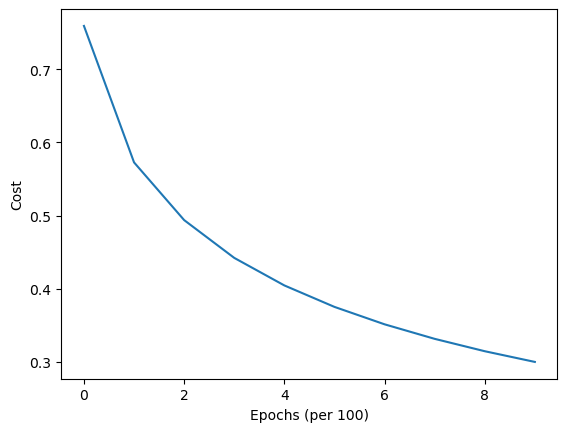

In [23]:
plt.plot(costs)
plt.ylabel('Cost')
plt.xlabel("Epochs (per 100)")
print(f"Learning rate = {learning_rate}")
plt.show()

## Test Model

In [24]:
def predict(X, w, b):
    """
    Use the trained weights and bias to make predictions on new images that the model hasn't seen yet

    Args:
        X: Input data, shape (n, 9)
        w: Weights, shape (1, 9)
        b: Bias, shape (1, 1)
    """
    Z = linear(X, w, b)
    probabilities = sigmoid(Z)

    # Sigmoid squashes the linear values to be between 0 or 1, (e.g prediction 0.32). We need to round that prediction to either 0 or 1, to get if the model is predicting a 0 for 'the image contains more black pixels than white pixels' or 1 otherwise!
    predictions = (probabilities > 0.5).astype(int)
    return predictions

**Test for one image** that the model hasn't seen yet

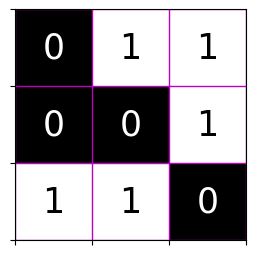

In [25]:
one_image, one_label = create_black_white_image_dataset(1)
draw_image_cell_image(one_image[0])

In [26]:
classes = ["contains more black pixels than white pixels", "contains more white pixels than black pixels"]
one_label = one_label.reshape(-1, 1)
one_image = one_image.reshape( 1, 9)
one_image_prediction = predict(one_image, w, b)
print(f"The model predicts that the above image {classes[one_image_prediction.item()]}.")

The model predicts that the above image contains more white pixels than black pixels.


**Test for Accuracy for many images** that the model hasn't seen yet.

In [27]:
num_samples_test = 2000 
images_test, labels_test = create_black_white_image_dataset(num_samples_test)
X_test = images_test.reshape( num_samples_test, 9)
Y_test = labels_test.reshape(-1, 1) # the reshape adds an extra dimension -> , 1)
test_predictions = predict(X_test, w, b)
test_predictions

array([[0],
       [1],
       [0],
       ...,
       [0],
       [0],
       [1]], shape=(2000, 1))

In [28]:
accuracy = np.mean(test_predictions == Y_test) * 100
print(f"Model Accuracy On A Test Set: {accuracy:.2f}%")

Model Accuracy On A Test Set: 100.00%


**Inspecting Training Parameters**

In [29]:
print("Weights:", w)
print("\nBias:", b)

Weights: [[1.11981058 1.08801937 1.1729765  1.12747901 1.17024012 1.11545949
  1.1780045  1.11301781 1.15997856]]

Bias: [[-4.98311535]]


All **9 weights** are positive and have a similar value. This means that the model learned that every pixel is equally important, and that a $1$ (a white pixel) should **positively** contribute to the final prediction, and vice versa for a $0$ should **negatively** contribute to the prediction.

The **bias** is a negative value that is around **-4.5**, it acts as a threshold.

⭐️ The model has learned to count the pixels and see if the count is greater than **~4.5** (bias). The formula the model has learnt:

$$sum(pixel * weight) + bias$$

- Since all weights are positive (~1), the above formula is `(sum of white pixels) + bias`

If an image contains 3 white pixels and 6 black pixels:

- $3.0 + (-4.5) = -1.5 $ → Sigmoid → $\sigma(-1.5)$ **<** $0.5$ → $0$, model predicts that this image has more black pixels than white pixels!

If an image contains 8 white pixels and 1 black pixel:

- $8 + (-4.5) = 3.5 $ → Sigmoid → $\sigma(3.5)$ **>** $0.5$ → $1$, model predicts that this image has more white pixels than black pixels!